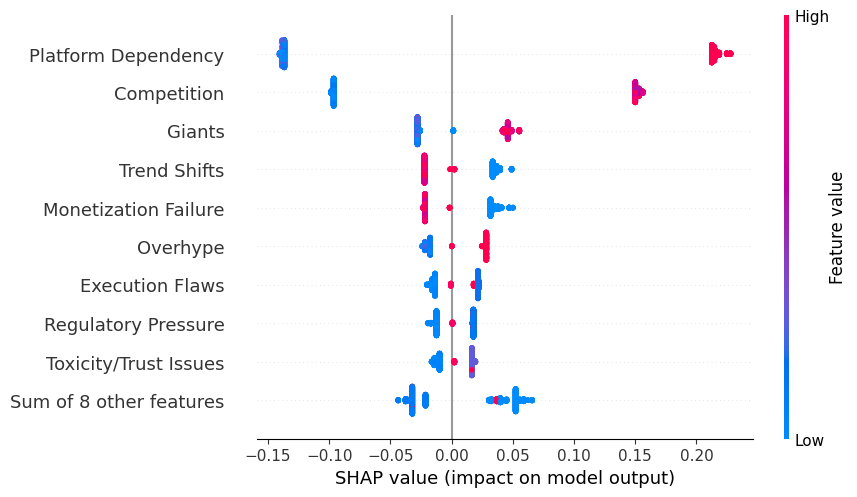

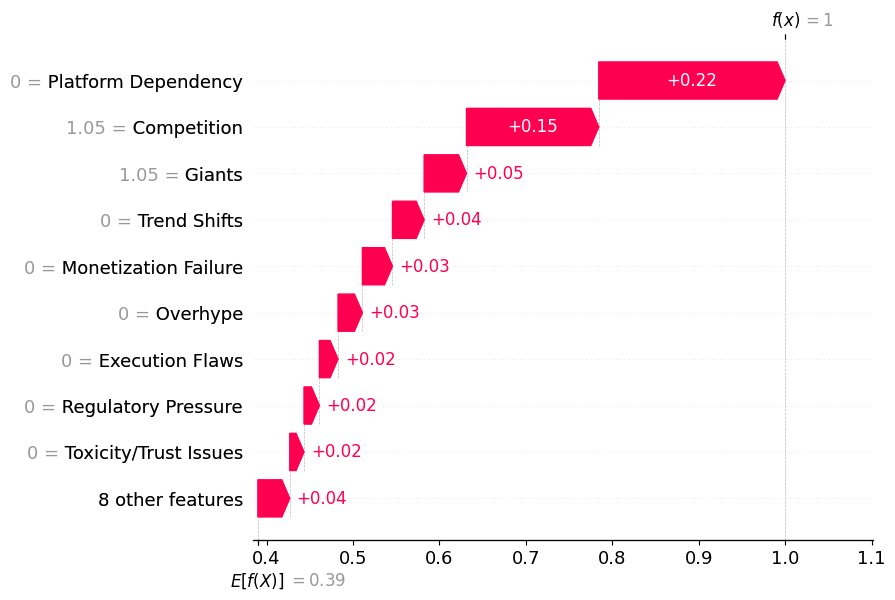

In [ ]:
import shap
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# LOAD DATA
df = pd.read_csv("../data/processed/final_dataset.csv")

# PREPROCESS
X = df.drop(columns=["failure", "startup_id"])

X = pd.get_dummies(X)
X = X.astype(float)
X = X.fillna(0)

# LOAD MODEL
model = joblib.load("../models/rf_model.pkl")

# FIXED EXPLAINER 
explainer = shap.Explainer(model, X)
shap_values = explainer(X)

# SUMMARY 
shap.plots.beeswarm(shap_values[:, :, 1])

# SINGLE EXPLANATION
shap.plots.waterfall(shap_values[0, :, 1])